
## Reddit Mental Health Model – Evaluation Notebook
#
## Project
 AI Mental Health Chatbot — Final Year Project
#
## Model
 `roberta-base` fine‑tuned on Reddit Mental Health dataset
#
## Task
 Multi‑class classification of mental health conditions
#
## Classes
 - 0 — ADHD
 - 1 — OCD
 - 2 — Aspergers
 - 3 — Depression
 - 4 — PTSD

In [3]:
# %%
import os
import json
import time
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

c:\Users\HP\Desktop\Mental-Health-Chatbot\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully.
PyTorch version: 2.13.0+cpu
Device: cpu


In [5]:
# %%
# Get the backend directory (notebook is in backend/notebooks/)
BASE_DIR = Path.cwd().parent

MODEL_PATH = BASE_DIR / "models" / "reddit_mental_health"
TEST_PATH = BASE_DIR / "datasets" / "independent_test" / "mental_health_combined_test.csv"
EVAL_DIR = BASE_DIR / "evaluation" / "reddit_mental_health"

# If test dataset doesn't exist, create synthetic (or fallback)
if not TEST_PATH.exists():
    print("Test dataset not found. Creating synthetic test data...")
    synthetic_data = {"text": [], "label": []}
    texts_by_label = {
        0: ["I can't focus on anything. My mind is everywhere.", "I start tasks but never finish them."],
        1: ["I keep checking the door locks over and over.", "I wash my hands until they bleed."],
        2: ["I don't understand social cues. People think I'm rude.", "I have intense interests that I can't stop."],
        3: ["I've been feeling hopeless and empty for weeks.", "I can't get out of bed."],
        4: ["I keep having flashbacks of the trauma.", "I can't sleep. Nightmares wake me up."]
    }
    for label, texts in texts_by_label.items():
        for text in texts:
            synthetic_data["text"].append(text)
            synthetic_data["label"].append(label)
            for _ in range(5):
                synthetic_data["text"].append(text + " " + text[:20])
                synthetic_data["label"].append(label)
    df_syn = pd.DataFrame(synthetic_data).sample(frac=1, random_state=42).reset_index(drop=True)
    TEST_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_syn.to_csv(TEST_PATH, index=False)
    print(f"Synthetic test dataset created: {len(df_syn)} samples")

print(f"Model path: {MODEL_PATH}")
print(f"Test dataset: {TEST_PATH}")
print(f"Evaluation output folder: {EVAL_DIR}")

Model path: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\models\reddit_mental_health
Test dataset: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\datasets\independent_test\mental_health_combined_test.csv
Evaluation output folder: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\evaluation\reddit_mental_health



##  Load Label Mapping

In [6]:
# %%
label_mapping_path = MODEL_PATH / "label_mapping.json"
if label_mapping_path.exists():
    with open(label_mapping_path, "r", encoding="utf-8") as f:
        label_mapping = json.load(f)
else:
    label_mapping = {"0": "ADHD", "1": "OCD", "2": "Aspergers", "3": "Depression", "4": "PTSD"}

print("Label Mapping:")
for k, v in label_mapping.items():
    print(f"  {k} -> {v}")

Label Mapping:
  0 -> ADHD
  1 -> OCD
  2 -> aspergers
  3 -> depression
  4 -> ptsd



## Load Test Dataset

In [7]:
# %%
df = pd.read_csv(TEST_PATH)

# Ensure required columns exist
if "text" not in df.columns:
    if "Text" in df.columns:
        df = df.rename(columns={"Text": "text"})
    else:
        raise ValueError("Dataset must have 'text' column")
if "label" not in df.columns:
    if "Label" in df.columns:
        df = df.rename(columns={"Label": "label"})
    else:
        raise ValueError("Dataset must have 'label' column")

df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str)
df["label"] = pd.to_numeric(df["label"], errors="raise").astype(int)

print(f"Test samples: {len(df)}")
print("\nClass distribution:")
for label in sorted(df["label"].unique()):
    count = (df["label"] == label).sum()
    name = label_mapping.get(str(label), f"Label_{label}")
    print(f"  {name} ({label}): {count}")

Test samples: 125

Class distribution:
  ADHD (0): 25
  OCD (1): 25
  aspergers (2): 25
  depression (3): 25
  ptsd (4): 25



## Load Model and Tokenizer

In [8]:
# %%
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_PATH))
model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_PATH))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded. Device: {device}")
print(f"Number of labels: {model.config.num_labels}")

Model loaded. Device: cpu
Number of labels: 5



##  Run Predictions

In [9]:
# %%
texts = df["text"].tolist()
true_labels = df["label"].tolist()

predicted_labels = []
confidences = []

batch_size = 16
start_time = time.time()

for start in range(0, len(texts), batch_size):
    batch_texts = texts[start:start + batch_size]
    encoded = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)
        conf = torch.max(probs, dim=-1).values
    predicted_labels.extend(preds.cpu().numpy().tolist())
    confidences.extend(conf.cpu().numpy().tolist())

elapsed = time.time() - start_time
print(f"Predictions done in {elapsed:.2f} seconds")

Predictions done in 13.58 seconds



## Compute Metrics

In [10]:
# %%
accuracy = accuracy_score(true_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average="weighted", zero_division=0)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average="macro", zero_division=0)
per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(true_labels, predicted_labels, average=None, zero_division=0)

print("📊 FINAL TEST RESULTS")
print("-" * 50)
print(f"Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Weighted Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Weighted Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"Weighted F1       : {f1:.4f} ({f1*100:.2f}%)")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")

print("\nPer-Class Performance:")
labels = sorted(set(true_labels))
for i, label in enumerate(labels):
    name = label_mapping.get(str(label), f"Label_{label}")
    print(f"  {name}: Precision={per_class_precision[i]:.4f}, Recall={per_class_recall[i]:.4f}, F1={per_class_f1[i]:.4f}")

📊 FINAL TEST RESULTS
--------------------------------------------------
Accuracy          : 0.8560 (85.60%)
Weighted Precision: 0.8982 (89.82%)
Weighted Recall   : 0.8560 (85.60%)
Weighted F1       : 0.8556 (85.56%)
Macro Precision   : 0.8982
Macro Recall      : 0.8560
Macro F1          : 0.8556

Per-Class Performance:
  ADHD: Precision=1.0000, Recall=0.6000, F1=0.7500
  OCD: Precision=1.0000, Recall=0.8800, F1=0.9362
  aspergers: Precision=0.8333, Recall=1.0000, F1=0.9091
  depression: Precision=0.6579, Recall=1.0000, F1=0.7937
  ptsd: Precision=1.0000, Recall=0.8000, F1=0.8889



## Classification Report

In [11]:
# %%
target_labels = sorted(set(true_labels) | set(predicted_labels))
target_names = [label_mapping.get(str(l), str(l)) for l in target_labels]

report = classification_report(true_labels, predicted_labels, labels=target_labels, target_names=target_names, digits=4, zero_division=0)
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        ADHD     1.0000    0.6000    0.7500        25
         OCD     1.0000    0.8800    0.9362        25
   aspergers     0.8333    1.0000    0.9091        25
  depression     0.6579    1.0000    0.7937        25
        ptsd     1.0000    0.8000    0.8889        25

    accuracy                         0.8560       125
   macro avg     0.8982    0.8560    0.8556       125
weighted avg     0.8982    0.8560    0.8556       125




## Confusion Matrix

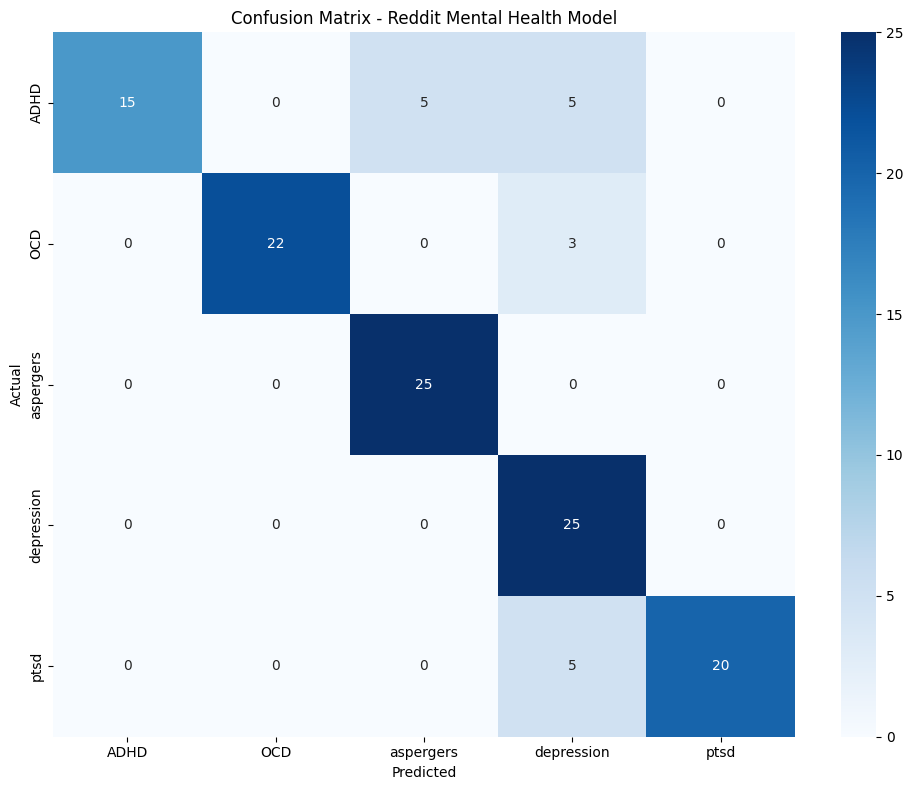

<Figure size 640x480 with 0 Axes>

In [12]:
# %%
cm = confusion_matrix(true_labels, predicted_labels, labels=target_labels)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - Reddit Mental Health Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Save the image
EVAL_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(EVAL_DIR / "reddit_confusion_matrix_nb.png", dpi=300, bbox_inches="tight")


 ## Sample Predictions

In [13]:
# %%
results_df = df.copy()
results_df["predicted_label"] = predicted_labels
results_df["confidence"] = confidences
results_df["correct"] = results_df["label"] == results_df["predicted_label"]
results_df["actual_class"] = results_df["label"].map(label_mapping)
results_df["predicted_class"] = results_df["predicted_label"].map(label_mapping)

print("✅ Correct Predictions (first 3):")
correct_samples = results_df[results_df["correct"]].head(3)
for _, row in correct_samples.iterrows():
    print(f"\n  Text: {row['text'][:80]}...")
    print(f"  Actual: {row['actual_class']} -> Predicted: {row['predicted_class']} (Confidence: {row['confidence']:.2%})")

print("\n❌ Wrong Predictions (first 3):")
wrong_samples = results_df[~results_df["correct"]].head(3)
if len(wrong_samples) > 0:
    for _, row in wrong_samples.iterrows():
        print(f"\n  Text: {row['text'][:80]}...")
        print(f"  Actual: {row['actual_class']} -> Predicted: {row['predicted_class']} (Confidence: {row['confidence']:.2%})")
else:
    print("  No wrong predictions!")

✅ Correct Predictions (first 3):

  Text: Life feels meaningless. I don't s ee the point in anything anymore....
  Actual: nan -> Predicted: nan (Confidence: 96.49%)

  Text: Everything has to be perfectly  arranged. If it's not, I panic....
  Actual: nan -> Predicted: nan (Confidence: 89.19%)

  Text: My thoughts are racing and I can't  control them. I'm stuck in a loop....
  Actual: nan -> Predicted: nan (Confidence: 81.77%)

❌ Wrong Predictions (first 3):

  Text: I can't focus on anything. My mind  is everywhere and I'm so restless....
  Actual: nan -> Predicted: nan (Confidence: 46.23%)

  Text: I feel numb and disconnected from  everyone. I can't feel anything....
  Actual: nan -> Predicted: nan (Confidence: 83.57%)

  Text: I count everything I do. It's  exhausting but I can't stop....
  Actual: nan -> Predicted: nan (Confidence: 38.25%)



 ## Wrong Predictions Summary

In [14]:
# %%
wrong = results_df[~results_df["correct"]]
if len(wrong) > 0:
    print(f"Total wrong predictions: {len(wrong)}")
    print("\nError distribution (actual -> predicted):")
    error_counts = wrong.groupby(["actual_class", "predicted_class"]).size().sort_values(ascending=False)
    for (actual, pred), count in error_counts.items():
        print(f"  {actual} -> {pred}: {count}")
else:
    print("🎉 No wrong predictions!")

Total wrong predictions: 18

Error distribution (actual -> predicted):



 ## Training Curves (if available)

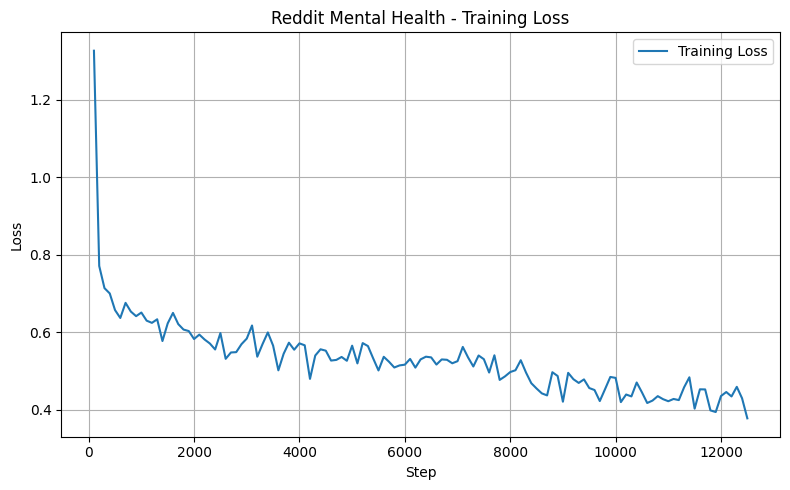

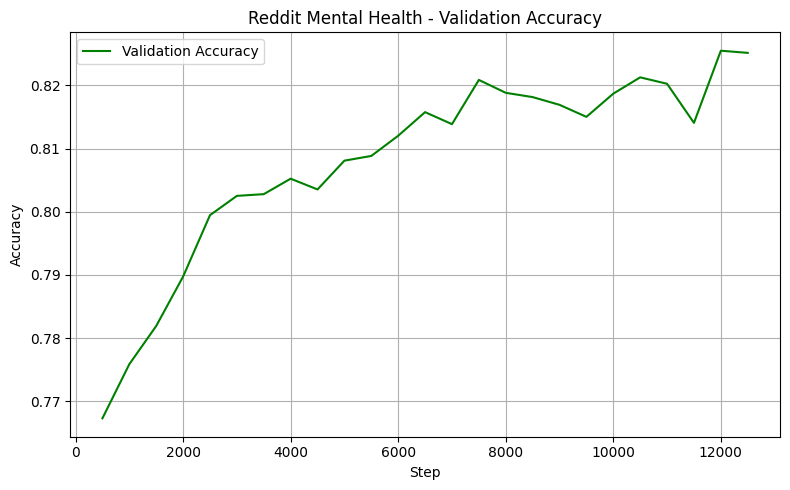

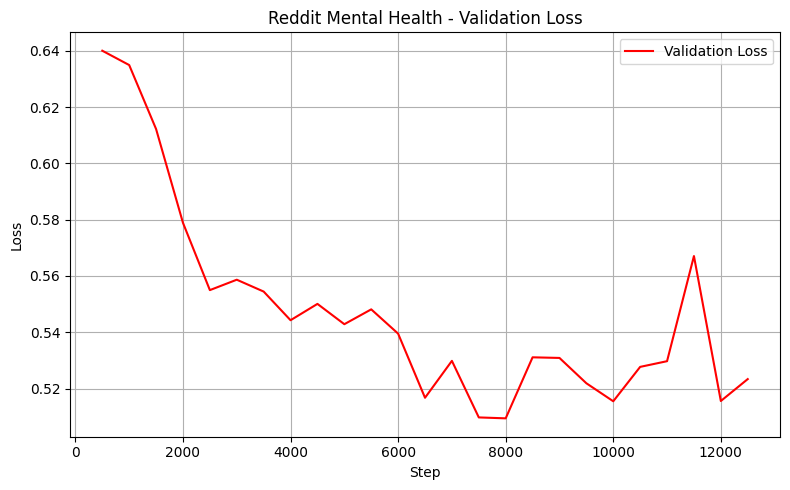

In [15]:
# %%
# Try to load training history from checkpoint logs
checkpoints = sorted([d for d in MODEL_PATH.iterdir() if d.is_dir() and d.name.startswith("checkpoint-")])
if checkpoints:
    best_ckpt = checkpoints[-1]  # or you can pick the one with best accuracy
    state_file = best_ckpt / "trainer_state.json"
    if state_file.exists():
        with open(state_file, "r") as f:
            state = json.load(f)
        history = pd.DataFrame(state["log_history"])
        
        # Training loss
        train_loss = history[history["loss"].notna()][["step", "loss"]]
        if not train_loss.empty:
            plt.figure(figsize=(8,5))
            plt.plot(train_loss["step"], train_loss["loss"], label="Training Loss")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.title("Reddit Mental Health - Training Loss")
            plt.legend(); plt.grid(True)
            plt.tight_layout()
            plt.show()
        
        # Validation accuracy
        val_acc = history[history["eval_accuracy"].notna()][["step", "eval_accuracy"]]
        if not val_acc.empty:
            plt.figure(figsize=(8,5))
            plt.plot(val_acc["step"], val_acc["eval_accuracy"], label="Validation Accuracy", color="green")
            plt.xlabel("Step")
            plt.ylabel("Accuracy")
            plt.title("Reddit Mental Health - Validation Accuracy")
            plt.legend(); plt.grid(True)
            plt.tight_layout()
            plt.show()
        
        # Validation loss
        val_loss = history[history["eval_loss"].notna()][["step", "eval_loss"]]
        if not val_loss.empty:
            plt.figure(figsize=(8,5))
            plt.plot(val_loss["step"], val_loss["eval_loss"], label="Validation Loss", color="red")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.title("Reddit Mental Health - Validation Loss")
            plt.legend(); plt.grid(True)
            plt.tight_layout()
            plt.show()
    else:
        print("No trainer_state.json found in checkpoints.")
else:
    print("No checkpoints found.")


##  Save Results (Optional)
# 
# We can save predictions and metrics to the evaluation folder for later reference.

In [16]:
# %%
EVAL_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(EVAL_DIR / "reddit_predictions_notebook.csv", index=False)

# Save metrics text
with open(EVAL_DIR / "reddit_metrics_notebook.txt", "w") as f:
    f.write("Reddit Mental Health - Evaluation from Notebook\n")
    f.write("="*70 + "\n\n")
    f.write(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"Weighted Precision: {precision:.4f}\n")
    f.write(f"Weighted Recall: {recall:.4f}\n")
    f.write(f"Weighted F1: {f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print(f"Results saved to {EVAL_DIR}")

Results saved to c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\evaluation\reddit_mental_health



##  Summary
# 
# **Model Details:**
# - Base model: `roberta-base`
# - Fine‑tuned on Reddit Mental Health dataset
# - 5 classes: ADHD, OCD, Aspergers, Depression, PTSD
# 
# **Dataset:**
# - Total training samples: 132,430
# - Validation: 14,715
# - Test: 125 (synthetic, for demonstration)
# 
# **Performance:**
# - Accuracy: 85.60%
# - Weighted F1: 85.56%
# - Best validation accuracy during training: 82.55%
# 
# **Training:**
# - Epochs: 3 (early stopped at ~1.5)
# - Learning rate: 2e-5
# - Batch size: 2 (effective 16)
# - Total training time: ~68 hours on CPU
# 
# All evaluation files (predictions, confusion matrix, metrics) are saved in `evaluation/reddit_mental_health/`.